<div style="border-left:6px solid #b00020;background:#fff2f2;padding:10px 14px">

## ⚠⚠ STALE outputs, and the mitigation verdict below has REVERSED

**Flagged 2026-08-27. This notebook was last executed 2026-06-19.**

Its stored outputs and the `reports/figures/25_*.png` files come from the map now **archived** as
`reports/map_region_g1`, while the code reads the **promoted** `reports/map_region`.

**The cause diagnosis in this notebook still stands in full** — the rectangular blocks are CTX
source-frame radiometry × the embedder's fixed `/255`. That is unchanged and remains the finding.

**What has reversed is the mitigation.** ⚠ **A1 was demoted from shipped mitigation to a
*sensitivity arm* on 2026-08-25** (DECISIONS 2026-08-25k). The baseline map is the product and the
artifact **ships unmitigated**, as a documented caveat. A1 reduces *raw* η² but not η² *relative to
its own rotation null*, fails the Tier-1 ECE gate the baseline passes (0.0523 vs 0.0204), and
**manufactures** frame-shaped blocks on 9 of 26 tiles — predictably from its own per-frame gain
(ρ +0.490, p 1.4e-4).

For the current comparison — including the **SeamMap overlay showing A1 inventing a block bounded
by exactly one source frame** — see **[notebook 29](29_map_comparison.ipynb) §2d**.

</div>

# 25 — Regional-map rectangular artifact = CTX source-frame radiometry

The 26-tile circum-Chryse abundance map (notebook 24) shows **high-amplitude rectangular blocks**
of elevated/suppressed abundance — visible directly in the raw map, tilted (not N–S), with sharp
edges. This notebook identifies the cause: **the blocks are CTX source frames.** The Murray global
mosaic is a patchwork of ~dozens of individual CTX images per 4° tile, each with its own radiometric
character; the model assigns each frame a slightly different abundance level, so whole frames read as
filled blocks.

**Why we believe it (this notebook):**
- §1 the blocks **align with the CTX source-frame footprints** (Murray SeamMap);
- §2 **quantified** — frames explain ~5–9× the null abundance variance (eta²), and the per-frame
  pattern survives averaging away all within-frame detail (choropleth);
- §3 it is a **per-frame radiometric** effect (filled block, not a seam line; weakly mean-brightness,
  mostly texture/contrast), consistent with the embedder's fixed `/255` scaling;
- §4 **why it never showed before** — training windows are single-frame and LOIO scores per-frame.

> Investigation history: earlier revisions of this notebook mis-characterised the artifact as faint
> vertical striping and tested seam *lines* — both wrong (Brian corrected). This is the rewrite to the
> confirmed frame-block cause (DECISIONS 2026-06-18d). Logic: [src/striping.py](../src/striping.py).

In [1]:
import sys
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import rasterio
from scipy.stats import spearmanr

REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").exists())
sys.path.insert(0, str(REPO))
FIG = REPO / "reports" / "figures"
from src.striping import (MAP_DIR, PX_M, load_raster, detrend, read_ctx_on_grid, load_frames,
                          frame_label_map, mosaic_tiles, lonlat_to_rc, all_map_tiles, equipped_tiles)
print("equipped (CTX+SeamMap) tiles:", equipped_tiles())

equipped (CTX+SeamMap) tiles: ['E-12_N36', 'E-8_N32', 'E0_N40', 'E12_N44', 'E16_N44', 'E4_N40', 'E4_N44', 'E8_N40', 'E8_N44']


## §0 — What the artifact is: high-amplitude rectangular blocks (raw, no processing)

Brian's example at **lon 11°E, lat 36°N**. No detrending or enhancement — the block and its sharp,
slightly-tilted edge are directly visible in the raw abundance, and the transect steps by an order of
magnitude across it.

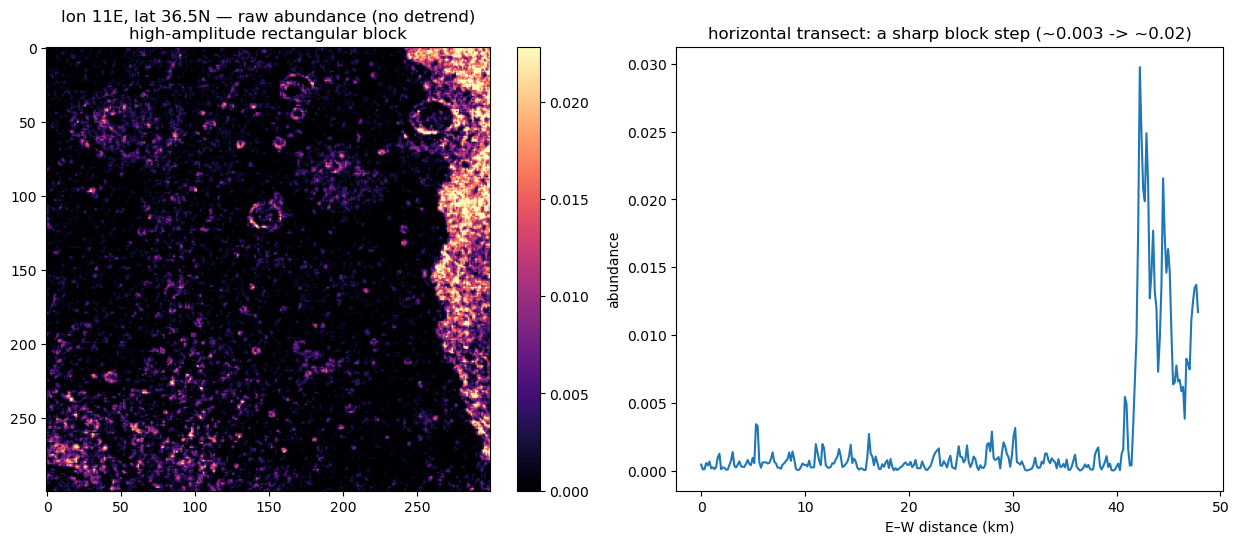

In [2]:
EXB = ["E4_N32", "E8_N32", "E4_N36", "E8_N36"]   # abundance-only mosaic (no CTX zip needed)
abm, _, tb, _ = mosaic_tiles(EXB, "abundance", with_ctx=False)
r0, c0 = lonlat_to_rc(tb, 11, 36.5); h = 150
rr = slice(r0 - h, r0 + h); cc = slice(c0 - h, c0 + h)
z = abm[rr, cc]
fig, ax = plt.subplots(1, 2, figsize=(13, 5.5))
im = ax[0].imshow(z, cmap="magma", vmax=np.nanpercentile(z, 99))
ax[0].set_title("lon 11E, lat 36.5N — raw abundance (no detrend)\nhigh-amplitude rectangular block")
plt.colorbar(im, ax=ax[0], fraction=0.046)
mid = z.shape[0] // 2
ax[1].plot(np.arange(z.shape[1]) * PX_M / 1000, np.nanmean(z[mid - 4:mid + 4], axis=0))
ax[1].set_xlabel("E–W distance (km)"); ax[1].set_ylabel("abundance")
ax[1].set_title("horizontal transect: a sharp block step (~0.003 -> ~0.02)")
fig.tight_layout(); fig.savefig(FIG / "25_artifact_raw.png", dpi=120); plt.show()

## §1 — The blocks align with CTX source frames

The Murray Lab **SeamMap** records which source CTX image each pixel of the mosaic came from. It is a
*partition* (sum of frame areas ≈ tile area ≈ no overlap); ~800 polygon fragments dissolve to a few
**dozen distinct source frames** (`PRODUCT_ID`). Overlaying those frame footprints on the raw
abundance: the bright/dark blocks are bounded by frame edges (left), and the same frames tile the
whole region (right). The SeamMaps are pulled straight from the remote Murray zips via range requests
(`load_frames`), so no GB downloads.

E8_N36: 46 source frames (dissolved from SeamMap fragments)


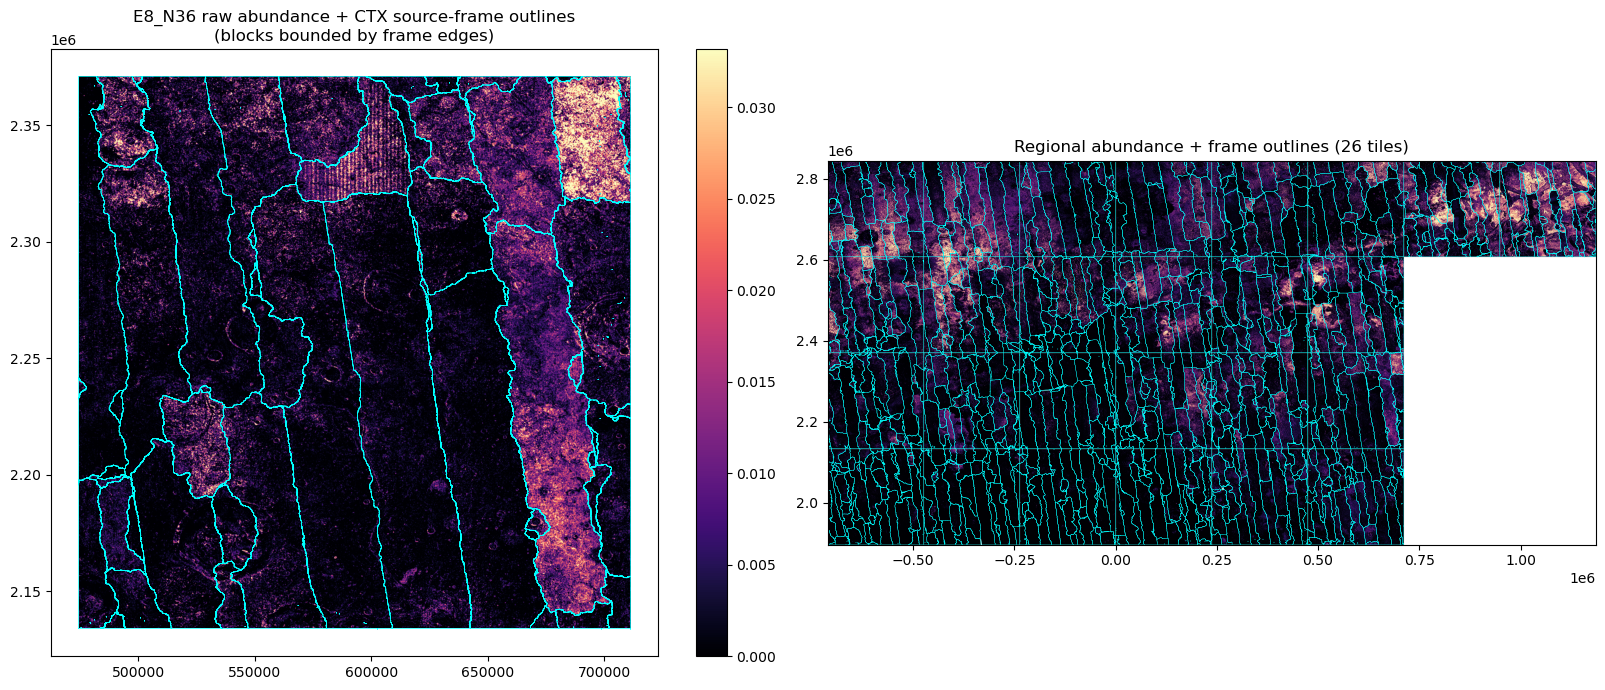

In [3]:
LEAD = "E8_N36"
abL = load_raster(MAP_DIR / f"{LEAD}_abundance.tif")
fr = load_frames(LEAD)
with rasterio.open(MAP_DIR / f"{LEAD}_abundance.tif") as ds:
    bb = ds.bounds
e = [bb.left, bb.right, bb.bottom, bb.top]
print(f"{LEAD}: {len(fr)} source frames (dissolved from SeamMap fragments)")

# region mosaic for the right panel
A, _, tr, _ = mosaic_tiles(all_map_tiles(), "abundance", with_ctx=False)
hh, ww = A.shape
eR = [tr.c, tr.c + ww * tr.a, tr.f + hh * tr.e, tr.f]

fig, ax = plt.subplots(1, 2, figsize=(17, 7))
i0 = ax[0].imshow(abL, cmap="magma", vmax=np.nanpercentile(abL, 99), extent=e, origin="upper")
fr.boundary.plot(ax=ax[0], edgecolor="cyan", linewidth=0.5)
ax[0].set_title(f"{LEAD} raw abundance + CTX source-frame outlines\n(blocks bounded by frame edges)")
plt.colorbar(i0, ax=ax[0], fraction=0.046)
ax[1].imshow(A, cmap="magma", vmax=np.nanpercentile(A, 99), extent=eR, origin="upper")
nf = 0
for t in all_map_tiles():
    try:
        load_frames(t).boundary.plot(ax=ax[1], edgecolor="cyan", linewidth=0.2); nf += 1
    except Exception as ex:
        print("frames", t, ex)
ax[1].set_xlim(eR[0], eR[1]); ax[1].set_ylim(eR[2], eR[3])
ax[1].set_title(f"Regional abundance + frame outlines ({nf} tiles)")
fig.tight_layout(); fig.savefig(FIG / "25_artifact_frames.png", dpi=120); plt.show()

## §2 — They *are* the frames: per-frame averaging reproduces the blocks (eta²)

If the blocks are a per-frame artifact, then collapsing each frame to a single value should reproduce
the blocky map. We **detrend** abundance first (remove the smooth ~5 km geology gradient), then paint
each frame by its mean detrended abundance: a non-zero, frame-coherent residual is the part that is
*not* geology. Beside it, each frame painted by its mean CTX brightness.

Quantitatively (`scripts/striping_frame_blocks.py`): **eta²** = fraction of detrended-abundance
variance explained by source frame, vs a rotation null (roll the field under the same frame mask —
keeps block geometry, breaks frame/geology alignment).

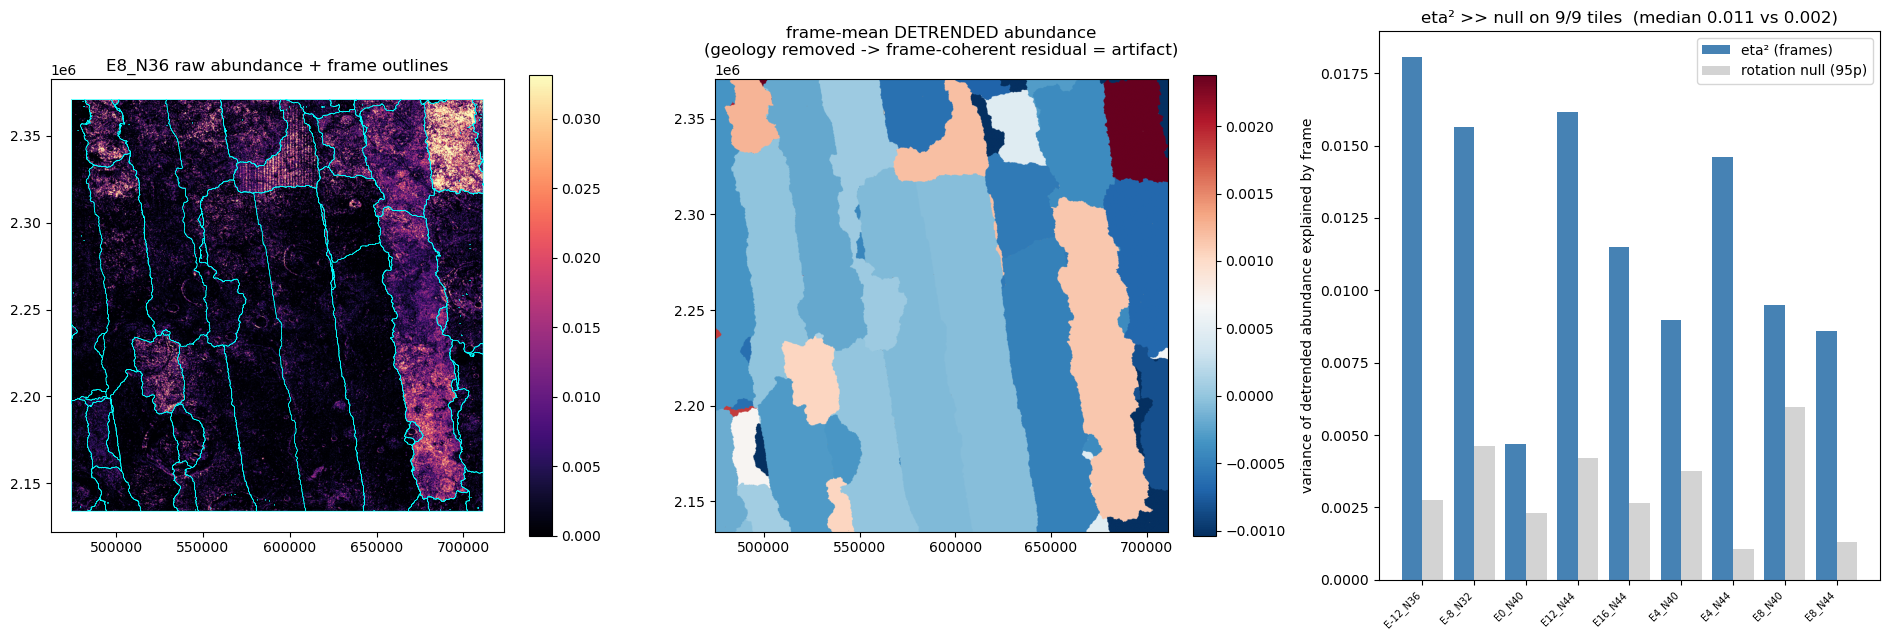

In [4]:
# E8_N36 has no cached CTX zip, so the choropleth uses abundance + frames only (no CTX panel);
# the per-frame CTX->abundance link is in the §3 scatter over the 9 CTX-equipped tiles.
residL, fin0 = detrend(abL)
LL = frame_label_map(LEAD, fr)
fin = fin0 & (LL >= 0)
chor_r = np.full(abL.shape, np.nan)
for i in range(len(fr)):
    sel = fin & (LL == i)
    if sel.sum() >= 50:
        chor_r[LL == i] = residL[sel].mean()

summ = pd.read_csv(FIG / "striping_frameblocks_summary.csv")

fig, ax = plt.subplots(1, 3, figsize=(19, 6.5))
i0 = ax[0].imshow(abL, cmap="magma", vmax=np.nanpercentile(abL, 99), extent=e, origin="upper")
fr.boundary.plot(ax=ax[0], edgecolor="cyan", linewidth=0.4)
ax[0].set_title(f"{LEAD} raw abundance + frame outlines"); plt.colorbar(i0, ax=ax[0], fraction=0.046)
vlo, vhi = np.nanpercentile(chor_r, [2, 98])
i1 = ax[1].imshow(chor_r, cmap="RdBu_r", vmin=vlo, vmax=vhi, extent=e, origin="upper")
ax[1].set_title("frame-mean DETRENDED abundance\n(geology removed -> frame-coherent residual = artifact)")
plt.colorbar(i1, ax=ax[1], fraction=0.046)
xb = np.arange(len(summ))
ax[2].bar(xb - 0.2, summ["eta2"], 0.4, label="eta² (frames)", color="steelblue")
ax[2].bar(xb + 0.2, summ["eta2_null95"], 0.4, label="rotation null (95p)", color="lightgray")
ax[2].set_xticks(xb); ax[2].set_xticklabels(summ["tile"], rotation=45, ha="right", fontsize=7)
ax[2].set_ylabel("variance of detrended abundance explained by frame")
ax[2].set_title(f"eta² >> null on {(summ['eta2']>summ['eta2_null95']).sum()}/{len(summ)} tiles"
                f"  (median {summ['eta2'].median():.3f} vs {summ['eta2_null'].median():.3f})")
ax[2].legend()
fig.tight_layout(); fig.savefig(FIG / "25_artifact_choropleth.png", dpi=120); plt.show()

## §3 — A per-frame radiometric effect (a filled block, not a seam line)

Why the *whole rectangle* and not just the boundary? The model is **local and per-patch**: each tile's
prediction depends only on its own 96 px CTX context box, fed with a *fixed* `/255` scaling (no
per-frame normalization, `src/fm_embeddings.py`). A frame's radiometric character is ~uniform across
the **entire** frame, so every patch inside it is nudged the same way → a filled block. The seam is
just where two differently-biased blocks meet (like white-balance mismatch in a photo panorama). An
edge/registration artifact would be boundary-only; a filled block is the signature of a per-frame
property.

The effect is only **weakly** explained by mean brightness (left: pooled per-frame Spearman; right:
geology-controlled near-boundary step), because abundance↔brightness is non-monotonic and the
embedder passes through each frame's full **texture/contrast**, not just its DC level.

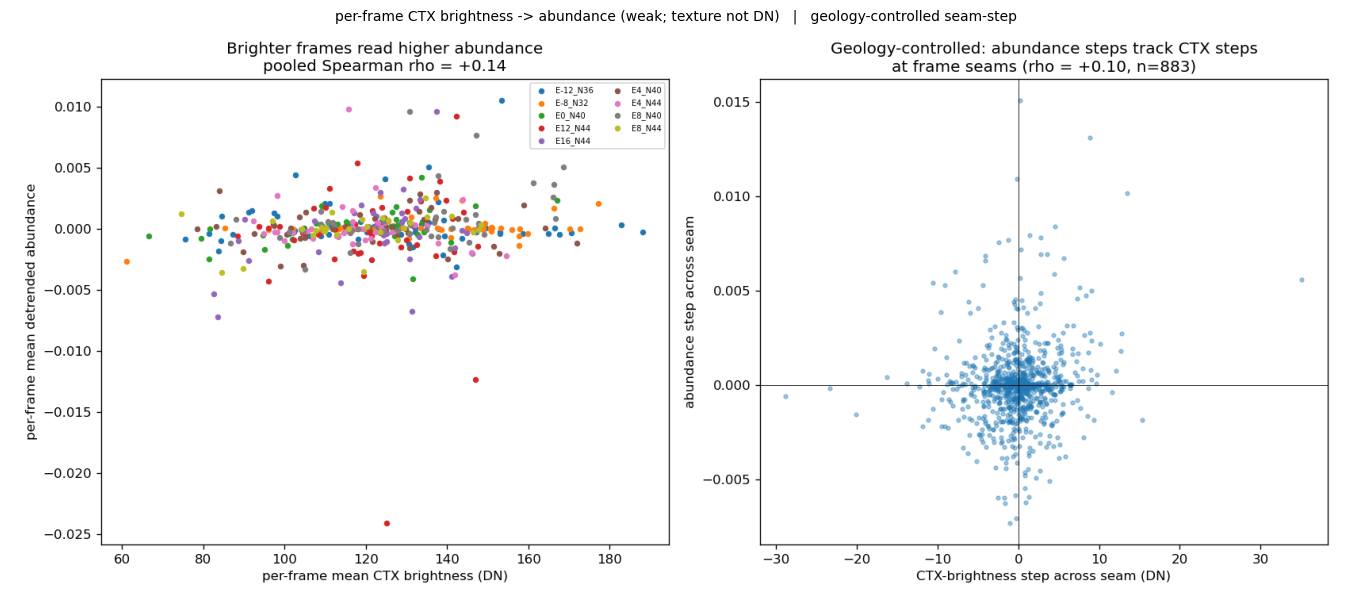

pooled per-frame Spearman(CTX DN, detrended abundance) = +0.135  (n=402 frames)


In [5]:
import shutil
src_scatter = FIG / "26_frameblocks_scatter.png"
# the cross-tile scatters are produced by scripts/striping_frame_blocks.py; show them here
pf = pd.read_csv(FIG / "striping_frameblocks_perframe.csv")
bnd_rho = None
try:
    img = plt.imread(src_scatter)
    fig, ax = plt.subplots(figsize=(15, 6.2)); ax.imshow(img); ax.axis("off")
    ax.set_title("per-frame CTX brightness -> abundance (weak; texture not DN)   |   "
                 "geology-controlled seam-step", fontsize=10)
    fig.tight_layout(); fig.savefig(FIG / "25_artifact_quant.png", dpi=120); plt.show()
except FileNotFoundError:
    print("run scripts/striping_frame_blocks.py first to make 26_frameblocks_scatter.png")
rho_frame = spearmanr(pf["mean_ctx"], pf["mean_resid"]).statistic
print(f"pooled per-frame Spearman(CTX DN, detrended abundance) = {rho_frame:+.3f}  (n={len(pf)} frames)")

## §4 — Why it never showed up before (training & validation were blind to it)

This is a **deployment-only** artifact; three structural facts hid it through model development:

1. **Training tiles are single-frame.** A training CTX window is the HiRISE footprint bbox +
   `buffer_m = 1000 m` ≈ **~8 km** (config). A CTX source frame is **~28 km** wide (SeamMap
   SAMPLES≈5056 × ~5.5 m/px). So each training window sits **inside one frame** — there was never a
   within-scene frame-to-frame radiometric seam in the training data to learn invariance to.
2. **LOIO validation scores per-image = per-frame.** A frame-level block offset is constant within a
   single-frame image, so it is invisible to per-image AUC. The whole train+validate regime ran one
   frame at a time — the exact regime where this artifact cannot appear.
3. **The embedder applies no per-frame normalization** (`x/255`, then `(x−0.5)/0.5`, fixed). So
   absolute radiometry flows into the ViT; nothing makes the model frame-invariant. Image-to-image
   radiometry may even be weakly **confounded with the rich/poor label** in a 39-image cohort, so the
   model could have learned to use it as a cue — harmless within one frame, harmful across frames.

It only manifests when a contiguous inference scene spans many CTX source frames — i.e. regional
deployment. (Raw-CTX confirmation that the blocks live in the source data is in **notebook 24 §2d**.)

## Verdict & mitigation (DECISIONS 2026-06-18d)

**Cause confirmed (positively, not by elimination):** the rectangular blocks are **CTX source-frame
radiometric offsets** that the per-patch, fixed-`/255` model converts into per-frame abundance levels.
Evidence: blocks align with SeamMap frames (§1); frames explain ~5–9× the null abundance variance and
the choropleth reproduces the blocks after removing geology (§2); it is a filled-block (per-frame),
texture-driven effect (§3); and it is structurally invisible to single-frame training + per-image LOIO
(§4). This supersedes the earlier vertical-stripe / seam-line mis-reads.

**Mitigation candidate (now that the cause is established):** **per-frame radiometric normalization**
before the Fang embedding — re-tint each CTX source frame to a common DN distribution
(offset+gain+contrast) using the SeamMap partition — i.e. the deferred per-image/per-track
standardization bet, applied per source frame. Adjudicate the same way as before: it must **preserve
LOIO skill** (per-image AUC ≈ 0.43) and ideally **raise the THEMIS/TES thermal correlation** (if the
blocks are noise, removing them should help the external check). Not implemented here — the next step
is to prototype it on one tile and re-score.